# Visualizations of MDN

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

### Training the MDN

Input mean: [6049.673828125, 0.4815983474254608, 0.5023599863052368]
Input std : [2097.983154296875, 0.1984938532114029, 0.23896823823451996]
Output mean: [0.48537585139274597, 0.5032348036766052]
Output std : [0.21043580770492554, 0.25154367089271545]
Starting training using 7000 training samples and 3000 validation samples.


Training MDN: 100%|██████████| 50/50 [00:05<00:00,  8.51epoch/s]


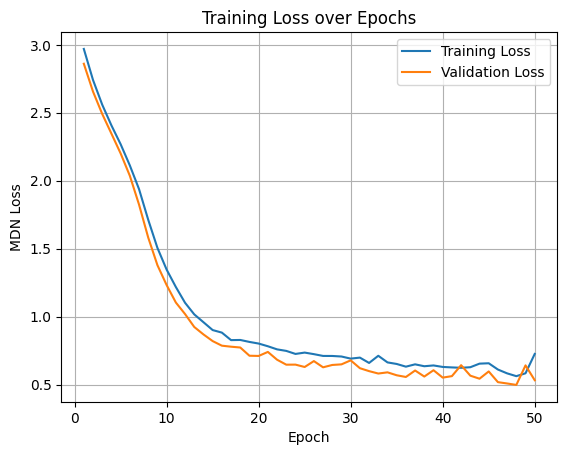

In [5]:
import torch
import numpy as np
from mdn import data_preparation, train_model, MixtureDensityNetwork

gas = "H2H2"
batch_size =256
num_epochs = 50

# import data
if gas == "O2O2":
    DATA = "datasets/O2O2_collisions.csv"
elif gas == "H2H2":
    DATA = "datasets/H2H2_collisions.csv"
rawdata = np.loadtxt(DATA, delimiter=',', skiprows=1)

# Make train/validation split
train_size = int(0.7 * rawdata.shape[0])
val_size = rawdata.shape[0] - train_size

# Convert to the variable set (Ec, \eta_trans, \eta_rot_A)
inputdata = np.zeros((rawdata.shape[0], 3))
inputdata[:,0] = np.sum(rawdata[:,0:3], axis=1)
inputdata[:,1] = rawdata[:,0]/inputdata[:,0] 
inputdata[:,2] = rawdata[:,1] / np.sum(rawdata[:,1:3], axis=1)

outputdata = np.zeros((rawdata.shape[0], 2))
outputdata[:,0] = rawdata[:,3]/np.sum(rawdata[:,3:6], axis=1)
outputdata[:,1] = rawdata[:,4]/ np.sum(rawdata[:,4:6], axis=1)

# Create Dataloaders for training and validation (with normalization)
inputs = torch.tensor(inputdata, dtype=torch.float32)
outputs = torch.tensor(outputdata, dtype=torch.float32)

train_loader, val_loader, in_mean, in_std, out_mean, out_std = data_preparation(inputs, outputs, train_size, val_size, batch_size=batch_size)

# Initialize the model
K = 5
output_dim = 2
model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=output_dim,
    num_mixtures=K,
    hidden_dim=128
)

# Train the model
train_model(model, train_loader, val_loader, in_mean, in_std, out_mean, out_std, num_epochs=num_epochs)

# Save model and normalization stats
if gas == "O2O2":
    torch.save({
        'model_state_dict': model.state_dict(),
        'in_mean': in_mean,
        'in_std': in_std,
        'out_mean': out_mean,
        'out_std': out_std
    }, "trainedmodels/mdn_O2O2_collision_model.pth")
elif gas == "H2H2":
    torch.save({
        'model_state_dict': model.state_dict(),
        'in_mean': in_mean,
        'in_std': in_std,
        'out_mean': out_mean,
        'out_std': out_std
    }, "trainedmodels/mdn_H2H2_collision_model.pth")

### Scatterplots of predicted vs true velocities

Finished plot 1
Finished plot 2
Finished plot 3
Finished plot 4


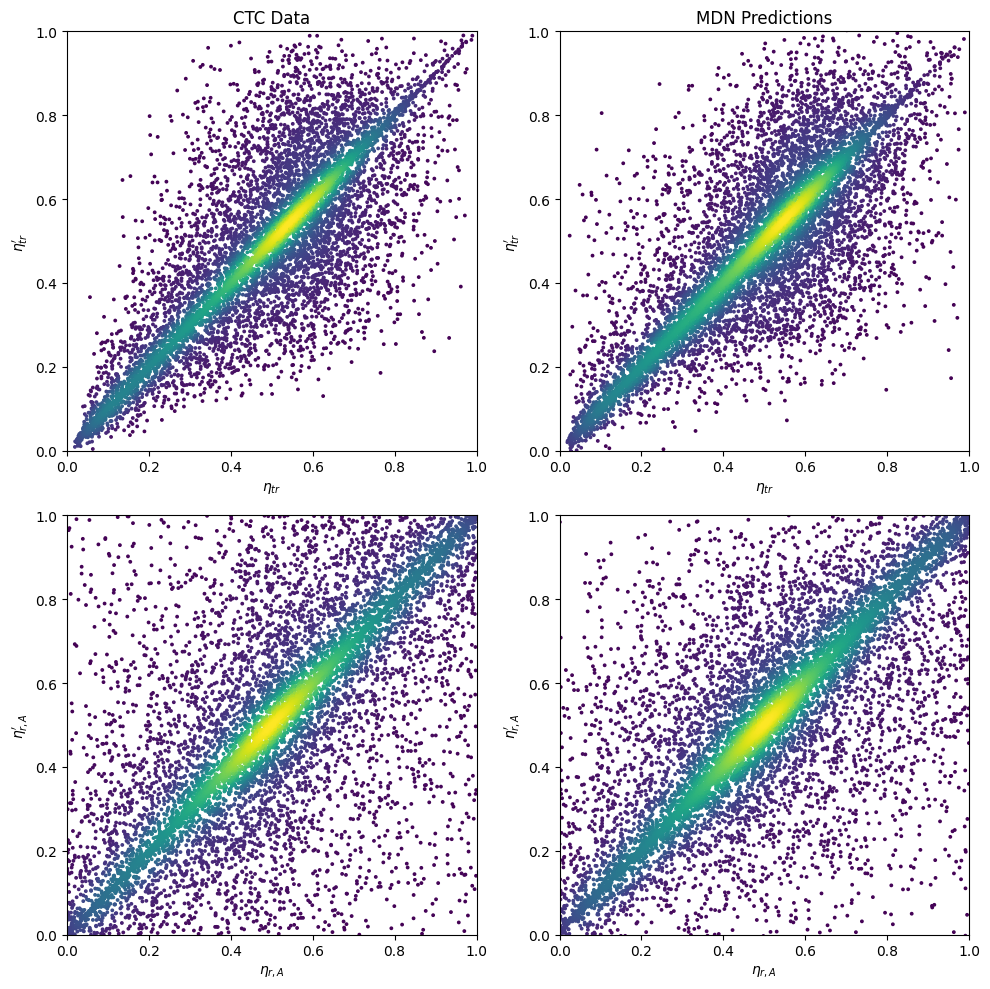

In [6]:
import torch
import numpy as np
from mdn_utils import plot_scattering_comparison
from mdn import MixtureDensityNetwork
from time import time

# Load model
if gas == "O2O2":
    model_path = "trainedmodels/mdn_O2O2_collision_model.pth"
elif gas == "H2H2":
    model_path = "trainedmodels/mdn_H2H2_collision_model.pth"
ckpt = torch.load(model_path, map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt)
K = state_dict["pi_layer.weight"].shape[0]

mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(state_dict)

# plot comparison
plot_scattering_comparison(
    np.column_stack((inputdata, outputdata)),
    mdn_model,
    nr_samples = 10000,
    in_mean=ckpt.get("in_mean"),
    in_std=ckpt.get("in_std"),
    out_mean=ckpt.get("out_mean"),
    out_std=ckpt.get("out_std"),
)
